In [38]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras.layers import Conv2D, MaxPooling2D, Flatten

np.random.seed(0)

In [39]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [40]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


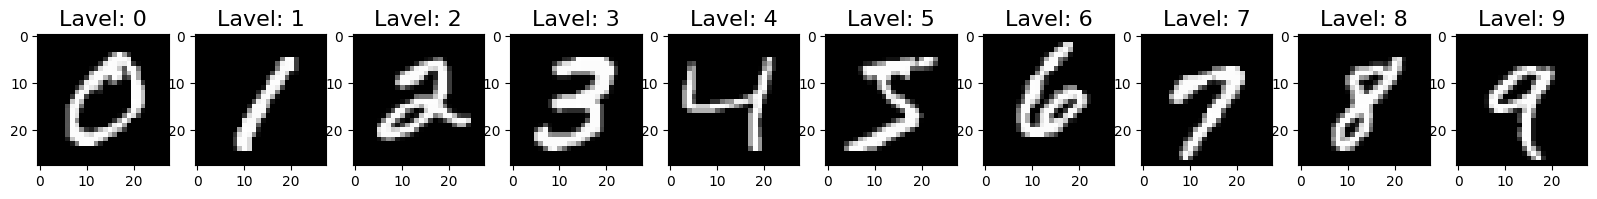

In [41]:
num_classes = 10
f, ax = plt.subplots(1, num_classes, figsize=(20,20))
for i in range(0, num_classes):
  sample = x_train[y_train == i][0]
  ax[i].imshow(sample, cmap='gray')
  ax[i].set_title("Lavel: {}".format(i), fontsize = 16)

In [42]:
for i in range(10):
  print(y_train[i])

5
0
4
1
9
2
1
3
1
4


In [43]:
y_train = keras.utils.to_categorical(y_train, num_classes)

In [44]:
y_test = keras.utils.to_categorical(y_test, num_classes)

In [45]:
for i in range(10):
  print(y_train[i])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [46]:
# normalization
x_train = x_train / 255.0
x_test = x_test / 255.0

In [47]:
# reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [48]:
# creating model

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [49]:
batch_size = 512
epochs=10
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 44s 356ms/step - accuracy: 0.8683 - loss: 0.4533
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 353ms/step - accuracy: 0.9703 - loss: 0.0986
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 353ms/step - accuracy: 0.9787 - loss: 0.0708
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 353ms/step - accuracy: 0.9826 - loss: 0.0573
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 43s 362ms/step - accuracy: 0.9845 - loss: 0.0495
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 353ms/step - accuracy: 0.9880 - loss: 0.0401
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 351ms/step - accuracy: 0.9890 - loss: 0.0352
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 355ms/step - accuracy: 0.9899 - loss: 0.0320
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 355ms/step - accuracy: 0.9916 - loss: 0.0280
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 353ms/step - accuracy: 0.9927 - loss: 0.0242


In [50]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("test loss: {}, test acc: {}".format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9907 - loss: 0.0259
test loss: 0.025862939655780792, test acc: 0.9907000064849854


In [51]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


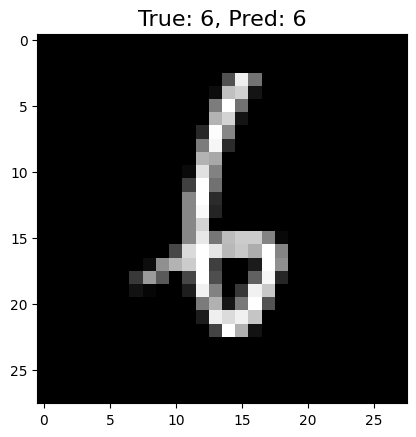

In [52]:
random_idx = np.random.choice(len(x_test))
x_sample = x_test[random_idx]
y_true = np.argmax(y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred = y_pred_classes[random_idx]

plt.title("True: {}, Pred: {}".format(y_sample_true, y_sample_pred), fontsize = 16)
plt.imshow(x_sample.reshape(28, 28), cmap='gray')

Text(0.5, 1.0, 'confusion matrix')

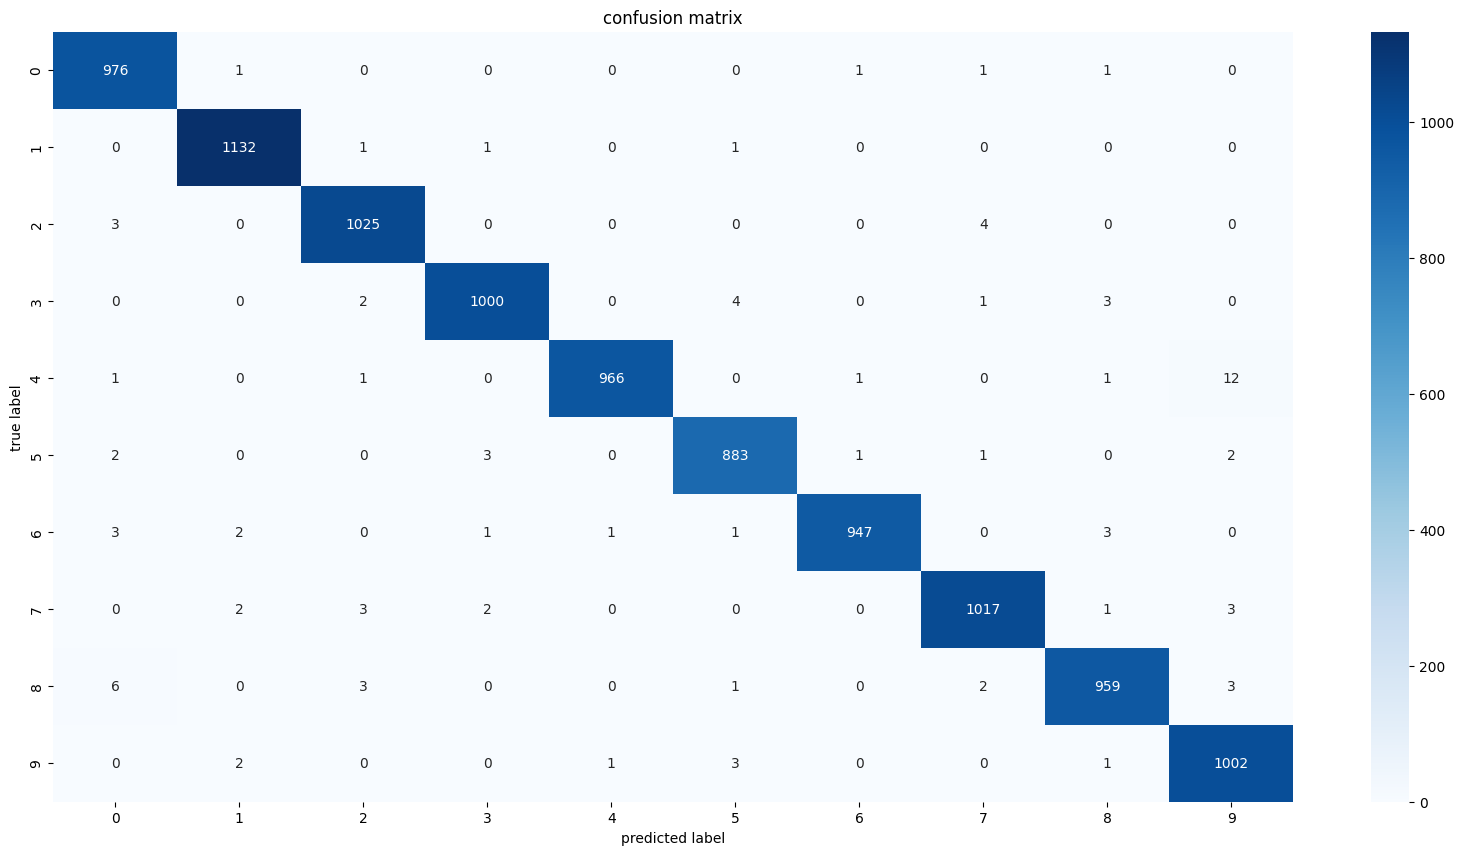

In [53]:
# confusion matrix
confusio_mtx = confusion_matrix(y_true, y_pred_classes)

# plot
fig, ax = plt.subplots(figsize=(20, 10))
ax = sns.heatmap(confusio_mtx, annot=True, fmt='d', ax=ax, cmap="Blues")
ax.set_xlabel('predicted label')
ax.set_ylabel('true label')
ax.set_title('confusion matrix')

In [54]:
errors = (y_pred_classes - y_true != 0)
y_pred_classes_errors = y_pred_classes[errors]
y_pred_errors = y_pred[errors]
y_true_errors = y_true[errors]
x_test_errors = x_test[errors]

In [55]:
y_pred_errors_prob = np.max(y_pred_errors, axis=1)
true_prob_errors = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1))
delta_pred_true_errors = y_pred_errors_prob - true_prob_errors

sorted_idx_errors = np.argsort(delta_pred_true_errors)
top_idx_errors = sorted_idx_errors[-6:]

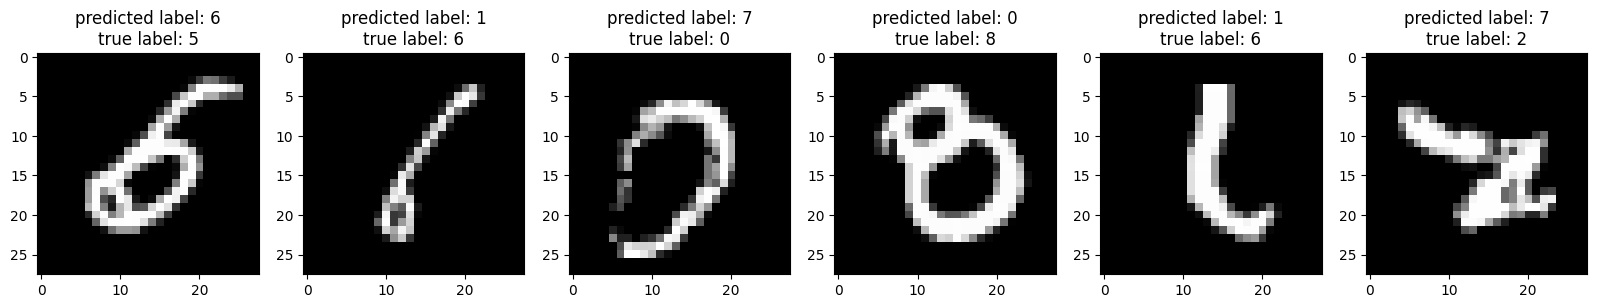

In [56]:
num = len(top_idx_errors)
f, ax = plt.subplots(1, num, figsize=(20,20))
for i in range(0, num):
  idx = top_idx_errors[i]
  sample = x_test_errors[idx].reshape(28, 28)
  y_t = y_true_errors[idx]
  y_p = y_pred_classes_errors[idx]
  ax[i].imshow(sample, cmap='gray')
  ax[i].set_title("predicted label: {}\ntrue label: {}".format(y_p, y_t, fontsize=22))

In [57]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"test accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9907 - loss: 0.0259
test accuracy: 0.9907
